   Year Temperature
0  1880        -.17
1  1881        -.09
2  1882        -.11
3  1883        -.18
4  1884        -.28


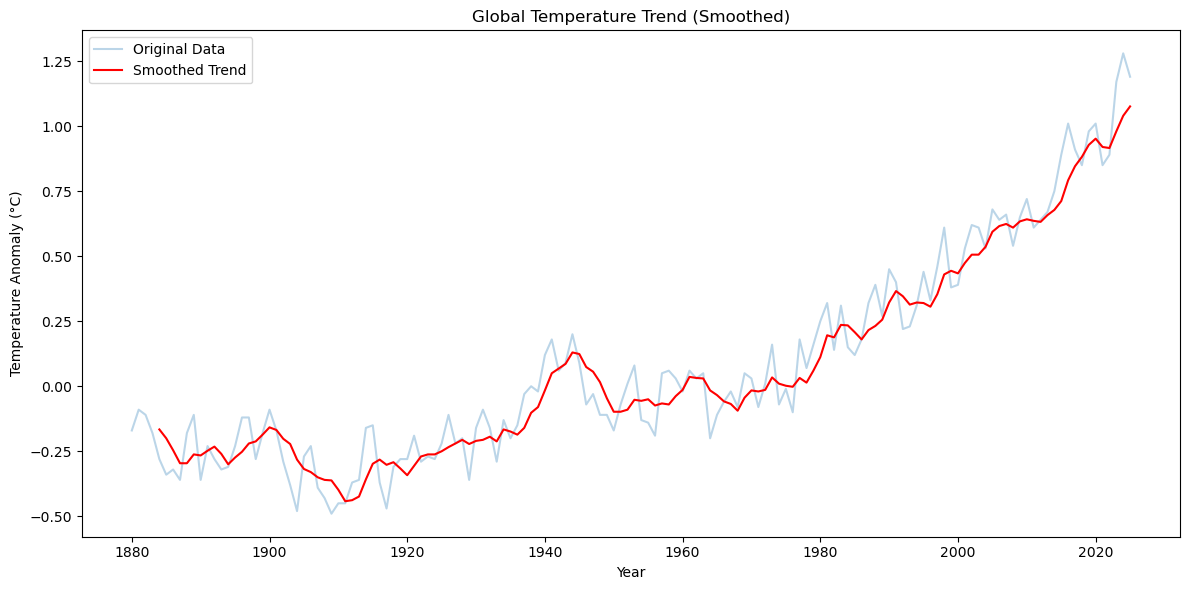

        Entity Code  Year  CO₂ emissions per capita
0  Afghanistan  AFG  1949                  0.001992
1  Afghanistan  AFG  1950                  0.010837
2  Afghanistan  AFG  1951                  0.011625
3  Afghanistan  AFG  1952                  0.011468
4  Afghanistan  AFG  1953                  0.013123
   Year       CO2
0  1949  0.001992
1  1950  0.010837
2  1951  0.011625
3  1952  0.011468
4  1953  0.013123
Year      int64
CO2     float64
dtype: object
   Year       CO2
0  1750  0.101538
1  1760  0.108314
2  1770  0.127649
3  1780  0.146632
4  1790  0.147515


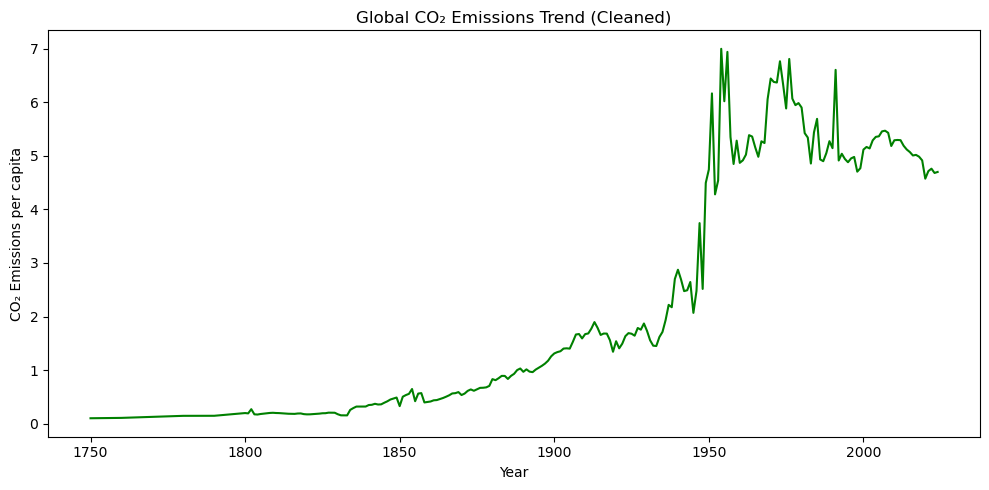

   Year  Temperature  Smoothed       CO2
0  1880        -0.17       NaN  0.831796
1  1881        -0.09       NaN  0.812279
2  1882        -0.11       NaN  0.848882
3  1883        -0.18       NaN  0.892372
4  1884        -0.28    -0.166  0.891705


In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset (skip header rows)
data = pd.read_csv("../data/temperature.csv", skiprows=1)

# Keep only required columns
data = data[['Year', 'J-D']]
data.columns = ['Year', 'Temperature']

# Remove missing values
data = data.dropna()

# Show cleaned data
print(data.head())

# Plot graph

import pandas as pd
import matplotlib.pyplot as plt

# Load data
data = pd.read_csv("../data/temperature.csv", skiprows=1)

# Clean columns
data = data[['Year', 'J-D']]
data.columns = ['Year', 'Temperature']

# Convert to numeric ⭐ FIX
data['Temperature'] = pd.to_numeric(data['Temperature'], errors='coerce')

# Remove missing values
data = data.dropna()

# Smooth data
data['Smoothed'] = data['Temperature'].rolling(window=5).mean()

# Plot
plt.figure(figsize=(12,6))

plt.plot(data['Year'], data['Temperature'], alpha=0.3, label="Original Data")
plt.plot(data['Year'], data['Smoothed'], color='red', label="Smoothed Trend")

plt.title("Global Temperature Trend (Smoothed)")
plt.xlabel("Year")
plt.ylabel("Temperature Anomaly (°C)")

plt.legend()
plt.grid(False)
plt.tight_layout()

plt.show()

co2 = pd.read_csv("../data/co2.csv")

print(co2.head())

co2 = co2[['Year', 'CO₂ emissions per capita']]

co2.columns = ['Year', 'CO2']

print(co2.head())

co2['CO2'] = pd.to_numeric(co2['CO2'], errors='coerce')

print(co2.dtypes)


co2_clean = co2.groupby('Year')['CO2'].mean().reset_index()

print(co2_clean.head())

plt.figure(figsize=(10,5))

plt.plot(co2_clean['Year'], co2_clean['CO2'], color='green')

plt.title("Global CO₂ Emissions Trend (Cleaned)")
plt.xlabel("Year")
plt.ylabel("CO₂ Emissions per capita")

plt.grid(False)
plt.tight_layout()

plt.show()

merged = pd.merge(data, co2_clean, on='Year')

print(merged.head())